In [1]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

  Cloning https://github.com/NetManAIOps/sktime.git to /tmp/pip-req-build-vwaietdl
  Running command git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /tmp/pip-req-build-vwaietdl
  Resolved https://github.com/NetManAIOps/sktime.git to commit 0187c6e07092f7b8a0d2787a36b27302f04394df
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 4.1 MB/s eta 0:00:00
  Created wheel for sktime: filename=sktime-0.40.1-py3-none-any.whl size=36374090 sha256=9777e0fa4872b666287520946383d3417a3f7f5404f5b14ab805a2c0d23f7a1d
  Stored in directory: /tmp/pip-ephem-wheel-cache-zhxjb56q/wheels/03/7e/fc/e38659894f6e29738ddf041859f11a018ea4f170d796e6ba4e
Successfully built sktime


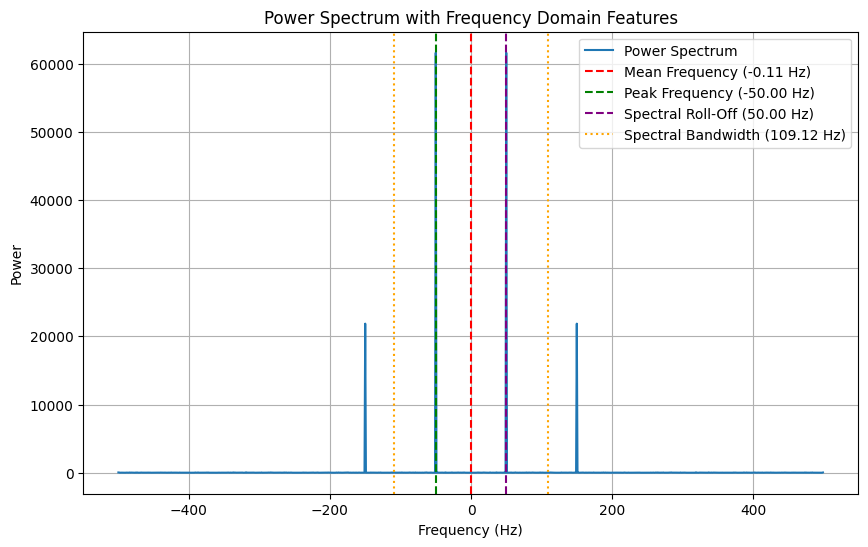

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a simple signal (sine waves + noise)
fs = 1000  # Sampling rate
T = 1/fs  # Sampling period
t = np.arange(0, 1, T)  # Time vector
f1 = 50  # Frequency of signal 1
f2 = 150  # Frequency of signal 2
signal = 0.5 * np.sin(2 * np.pi * f1 * t) + 0.3 * np.sin(2 * np.pi * f2 * t) + 0.1 * np.random.randn(len(t))  # Composite signal

# Compute Fourier Transform
n = len(signal)
f = np.fft.fftfreq(n, T)  # Frequency axis
f = np.fft.fftshift(f)  # Shift frequency from negative to positive
spectrum = np.fft.fft(signal)  # Fourier Transform
spectrum = np.fft.fftshift(spectrum)  # Shift spectrum

# Compute power spectrum
power_spectrum = np.abs(spectrum)**2

# Compute features
mean_freq = np.sum(f * power_spectrum) / np.sum(power_spectrum)  # Mean Frequency
peak_freq = f[np.argmax(power_spectrum)]  # Peak Frequency
centroid = np.sum(f * power_spectrum) / np.sum(power_spectrum)  # Spectral Centroid
bandwidth = np.sqrt(np.sum((f - centroid)**2 * power_spectrum) / np.sum(power_spectrum))  # Spectral Bandwidth
rolloff_freq = f[np.where(np.cumsum(power_spectrum)/np.sum(power_spectrum) >= 0.85)[0][0]]  # Spectral Roll-Off

# Plot power spectrum
plt.figure(figsize=(10, 6))
plt.plot(f, power_spectrum, label='Power Spectrum')
plt.title("Power Spectrum with Frequency Domain Features")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")

# Mark features
plt.axvline(mean_freq, color='r', linestyle='--', label=f'Mean Frequency ({mean_freq:.2f} Hz)')
plt.axvline(peak_freq, color='g', linestyle='--', label=f'Peak Frequency ({peak_freq:.2f} Hz)')
# plt.axvline(centroid, color='b', linestyle='--', label=f'Spectral Centroid ({centroid:.2f} Hz)')
plt.axvline(rolloff_freq, color='purple', linestyle='--', label=f'Spectral Roll-Off ({rolloff_freq:.2f} Hz)')

# Mark spectral bandwidth range
plt.axvline(centroid - bandwidth, color='orange', linestyle=':', label=f'Spectral Bandwidth ({bandwidth:.2f} Hz)')
plt.axvline(centroid + bandwidth, color='orange', linestyle=':')

# Show legend
plt.legend()

# Display plot
plt.grid(True)
plt.show()


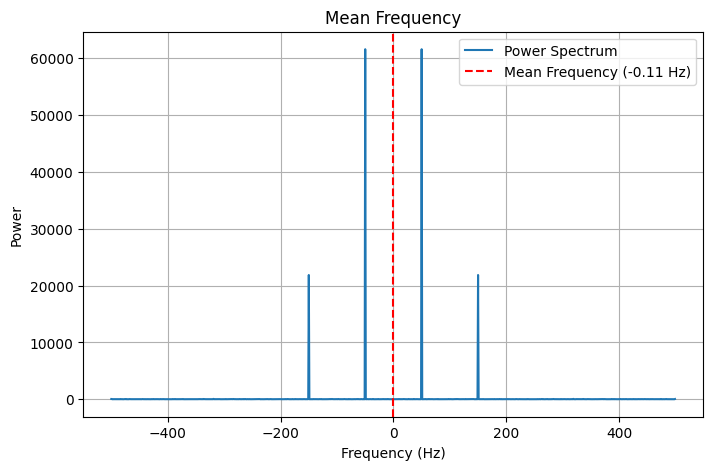

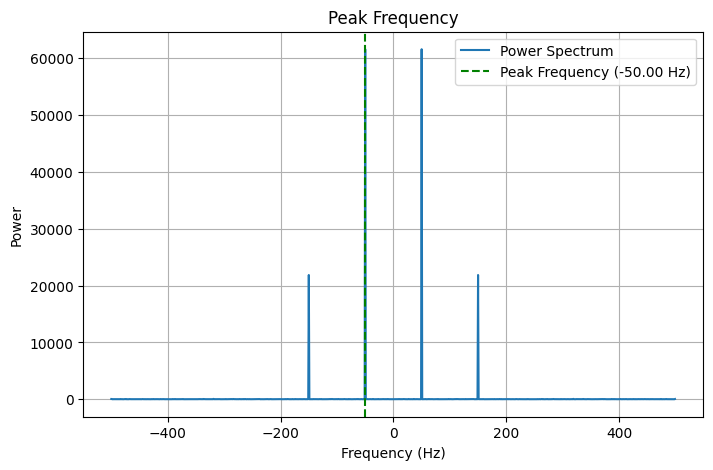

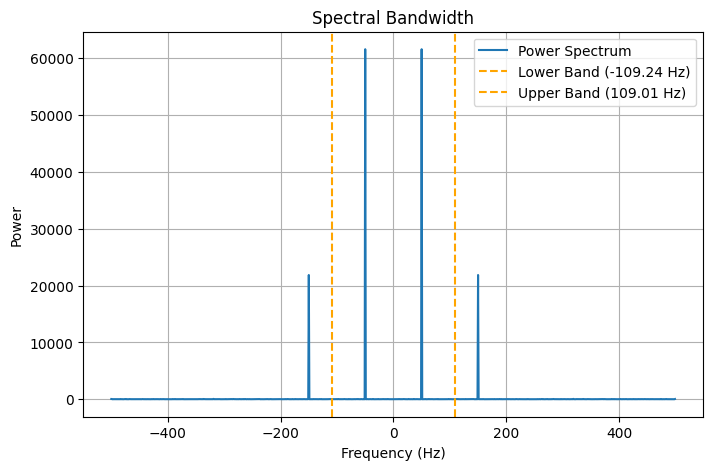

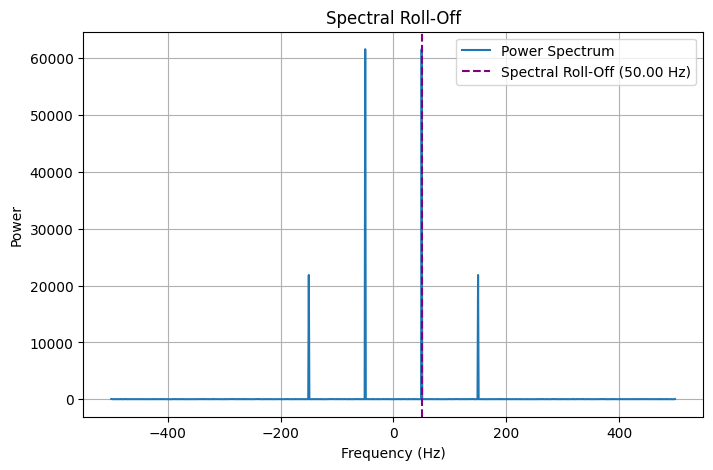

In [3]:
# Plot individual graphs for each feature
def plot_feature(title, feature_freqs, colors, labels):
    plt.figure(figsize=(8, 5))
    plt.plot(f, power_spectrum, label='Power Spectrum')
    for freq, color, label in zip(feature_freqs, colors, labels):
        plt.axvline(freq, color=color, linestyle='--', label=label)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.legend()
    plt.grid(True)
    plt.show()

# 1. Mean Frequency
plot_feature("Mean Frequency", [mean_freq], ['r'], [f'Mean Frequency ({mean_freq:.2f} Hz)'])

# 2. Peak Frequency
plot_feature("Peak Frequency", [peak_freq], ['g'], [f'Peak Frequency ({peak_freq:.2f} Hz)'])

# 3. Spectral Bandwidth
plot_feature("Spectral Bandwidth", [centroid - bandwidth, centroid + bandwidth],
             ['orange', 'orange'], [f'Lower Band ({centroid - bandwidth:.2f} Hz)', f'Upper Band ({centroid + bandwidth:.2f} Hz)'])

# 4. Spectral Roll-Off
plot_feature("Spectral Roll-Off", [rolloff_freq], ['purple'], [f'Spectral Roll-Off ({rolloff_freq:.2f} Hz)'])
